<a href="https://colab.research.google.com/github/SUSHMASURE11/Predictive-Analytics/blob/credit_card_fraud_detection/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1-1821905344.py:36: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


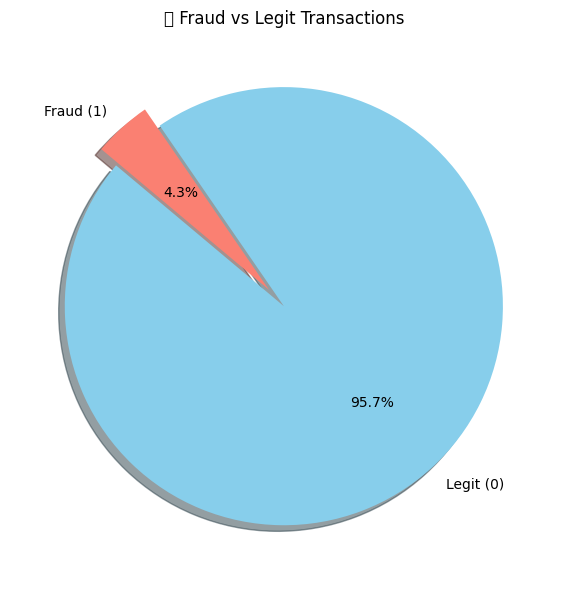

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

📊 Confusion Matrix:
 [[287   0]
 [ 13   0]]

📄 Classification Report:
               precision    recall  f1-score   support

           0     0.9567    1.0000    0.9779       287
           1     0.0000    0.0000    0.0000        13

    accuracy                         0.9567       300
   macro avg     0.4783    0.5000    0.4889       300
weighted avg     0.9152    0.9567    0.9355       300



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipython-input-1-1821905344.py:80: UserWarnin

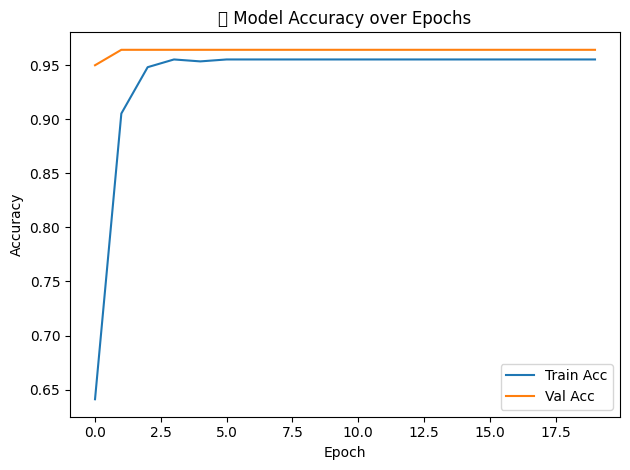

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Generate synthetic dataset
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'Amount': np.random.exponential(scale=100, size=n).round(2),
    'Time': np.random.randint(0, 24, size=n),
    'Transaction_Type': np.random.choice(['Online', 'POS', 'ATM'], size=n, p=[0.5, 0.4, 0.1]),
    'Location': np.random.choice(['Urban', 'Suburban', 'Rural'], size=n, p=[0.6, 0.3, 0.1]),
    'Is_Fraud': np.random.choice([0, 1], size=n, p=[0.95, 0.05])  # 5% fraud
})

# 2. Descriptive Analysis: Pie Chart
fraud_counts = df['Is_Fraud'].value_counts()
labels = ['Legit (0)', 'Fraud (1)']
colors = ['skyblue', 'salmon']
explode = [0, 0.1]

plt.figure(figsize=(6, 6))
plt.pie(fraud_counts, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, explode=explode, shadow=True)
plt.title('💳 Fraud vs Legit Transactions')
plt.tight_layout()
plt.show()

# 3. Preprocessing
X = df.drop('Is_Fraud', axis=1)
y = df['Is_Fraud']

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['Transaction_Type', 'Location'], drop_first=True)

# Scale numerical features
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# 4. Build Neural Network
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=0)

# 6. Evaluate
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📄 Classification Report:\n", classification_report(y_test, y_pred, digits=4))

# 7. Plot training history
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('📈 Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()